# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [2]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [58]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [60]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now = Time.now()

print("We have function which convert the UTC to IST - format_iitk(format_iitk(time_value)\n")

# Format and print the instant in ISO UTC and IIT Kanpur time (IST)
print("Current Time Representation")
print("Current ISO UTC:        ", format_utc(now))
print("Current IITK (IST):     ", format_iitk(now))



We have function which convert the UTC to IST - format_iitk(format_iitk(time_value)

Current Time Representation
Current ISO UTC:         2026-09-06 11:13:03 UTC
Current IITK (IST):      2026-09-06 16:43:03 IST


Ans -  Because the time.now() takes the snapshot of the exact time and give us the value but the processing time in the cpu for calling the same function twice will have microseconds delay which will be included in the snapshot of the exact time leading to two different time stamps for two seperate calls

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [61]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

GTC_height = 2396 * u.m
wavelength = 60 * u.nm
uncertainity_mas = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

# Perform conversions
height_km = GTC_height.to(u.km)
frequency_thz = wavelength.to(u.THz, equivalencies = u.spectral())
uncertainty_arcsec = uncertainity_mas.to(u.arcsec)
cadence_hours = cadence.to(u.hour)
wavelength_cm = frequency.to(u.cm, equivalencies=u.spectral())

# Printing original value beside its converted values
print("Physical Quantities and Conversions\n")

print(f"GTC Height:             {GTC_height} -> {height_km:.6f}")
print(f"Optical Wavelength:     {wavelength} -> {frequency_thz:.6f}")
print(f"Coordinate Uncertainty: {uncertainty_arcsec} -> {uncertainty_arcsec:.6f}")
print(f"Cadence:                {cadence} -> {cadence_hours:.6f}")
print(f"Radio Frequency:        {frequency} -> {wavelength_cm:.6f}")

Physical Quantities and Conversions

GTC Height:             2396.0 m -> 2.396000 km
Optical Wavelength:     60.0 nm -> 4996.540967 THz
Coordinate Uncertainty: 0.005 arcsec -> 0.005000 arcsec
Cadence:                10.0 min -> 0.166667 h
Radio Frequency:        1.4 GHz -> 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [63]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

planning_start = Time(START_UTC, scale = "utc")

print("Time Formats \n")
print("Original UTC:            ", format_utc(planning_start))
print("Julian Date (JD):        ", planning_start.jd)
print("Modified Julian Date(MJD):", planning_start.mjd)
print("IIT Kanpur Time (IST):   ", format_iitk(planning_start))

# Adding 2.25 hours using an Astropy Quantity
T = planning_start + 2.25 * u.hour
print("\nAfter adding 2.25 hours:")
print("Later UTC:               ", format_utc(T))
print("Later IST:               ", format_iitk(T))

# Verifying round-trip conversion via Python datetime
IST = planning_start.to_datetime(timezone=IITK_TIMEZONE)
# IST consist of the time in IST standard with label of +5hr 30 min ahead of UTC
# Converting the IST to UTC by feeding the python date time value to the Time object of the astropy
Utc = Time(IST)
time_difference = abs(Utc - planning_start).to(u.us)

print(f"\nRound-trip difference:    {time_difference:}")
print("Verification successful: Difference is less than 1 microsecond.")

Time Formats 

Original UTC:             2026-08-30 12:00:00 UTC
Julian Date (JD):         2461283.0
Modified Julian Date(MJD): 61282.5
IIT Kanpur Time (IST):    2026-08-30 17:30:00 IST

After adding 2.25 hours:
Later UTC:                2026-08-30 14:15:00 UTC
Later IST:                2026-08-30 19:45:00 IST

Round-trip difference:    0.0 us
Verification successful: Difference is less than 1 microsecond.


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [66]:
RA_angle = Angle(FRB_RA_J2000)
Dec_angle = Angle(FRB_DEC_J2000)

# using the parsed angle in the Skycoord
frb_icrs = SkyCoord(ra = RA_angle, dec = Dec_angle , frame = "icrs")

# Print decimal degrees and padded sexagesimal notation
print("Q4: Parse Angles and Construct ICRS Coordinate\n")
print(f"RA in decimal degrees:   {frb_icrs.ra.deg:.10f}°")
print(f"Dec in decimal degrees:  {frb_icrs.dec.deg:.10f}°")
print(f"RA sexagesimal:          {frb_icrs.ra.to_string(unit=u.hour, precision=4, sep='hms', pad=True)}")
print(f"Dec sexagesimal:         {frb_icrs.dec.to_string(unit=u.degree, precision=4, sep='dms', pad=True)}")

# Verifying coordinates within 10^-8 degree of course constants
expected_ra = 347.2704120833
expected_dec = 48.7066410556
ra_diff = abs(frb_icrs.ra.deg - expected_ra)
dec_diff = abs(frb_icrs.dec.deg - expected_dec)

print(f"RA verification diff:    {ra_diff:.12f}°")
print(f"Dec verification diff:   {dec_diff:.12f}°")
assert ra_diff < 1e-8, "RA verification failed!"
assert dec_diff < 1e-8, "Dec verification failed!"
print("Verification successful: Coordinates match within 10^-8 degrees.")


Q4: Parse Angles and Construct ICRS Coordinate

RA in decimal degrees:   347.2704120833°
Dec in decimal degrees:  48.7066410556°
RA sexagesimal:          23h09m04.8989s
Dec sexagesimal:         48d42m23.9078s
RA verification diff:    0.000000000033°
Dec verification diff:   0.000000000044°
Verification successful: Coordinates match within 10^-8 degrees.


Ans -  As the earth rotates the stars also cross our sky in every 24 hrs which is denotes by the RA, very hour of RA corresponds to exactly 15 degree of celestial rotation, allowing astronomers to immediately know when a star is going to transit on their local meridian. So it is dependent on the rotation of the earth thas it is measured in hours but declination is not dependent on the rotation it is a fixed coordinate on the sky which measures a fixed angular distance north or south of the celestial equator toward the celestial poles (from +90 to −90 degree) hence it is preferred in degrees

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [68]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
# frb_icrs to Galactic coordinates
frb_galactic_coord = frb_icrs.galactic

print("Q5: ICRS to Galactic and Back\n")
print(f"Galactic longitude l:    {frb_galactic_coord.l.deg:.10f}°")
print(f"Galactic latitude b:     {frb_galactic_coord.b.deg:.10f}°")

# Transforming the result back to ICRS
frb_back_icrs = frb_galactic_coord.transform_to('icrs')

# round-trip separation in microarcseconds (µas)
sep_deg = frb_icrs.separation(frb_back_icrs)
sep_microarcsec1 = np.degrees(sep_deg).to(u.uas)
print(f"Round-trip separation:   {sep_microarcsec1:.10f}")

Q5: ICRS to Galactic and Back

Galactic longitude l:    106.0649607733°
Galactic latitude b:     -10.7841762854°
Round-trip separation:   0.0003107329 uas


Ans - The tiny non-residual represents the floating precision and rounding technique which cpu use leads to error addition at every step. Converting these cooridnates requires matrix and trignometric calculation which leads to rounding off numbers leading to the difference in the round trip seperation.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [71]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

# Transforming to Barycentric True Ecliptic at J2000
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox='J2000'))

print("ICRS to Ecliptic and Back")

print(f"Ecliptic longitude lambda: {frb_ecliptic.lon.deg:.10f}°")
print(f"Ecliptic latitude beta:    {frb_ecliptic.lat.deg:.10f}°\n")

# Verifying valid coordinate ranges
if frb_ecliptic.lat.deg <= 360.0:
   print("Lambda is within the range")
else :
   print("Lambda is not valid")

if frb_ecliptic.lon.deg <= 360.0:
   print("Beta is within the range\n")
else:
    print("beta is not valid")


# Transforming back to ICRS
frb_back_to_icrs = frb_ecliptic.transform_to('icrs')

# round-trip separation in microarcseconds (µas)
seperation = frb_icrs.separation(frb_back_to_icrs).to(u.uas)
print(f"Round-trip separation:     {seperation:.10f}")

ICRS to Ecliptic and Back
Ecliptic longitude lambda: 14.4111876503°
Ecliptic latitude beta:    48.3469584374°

Lambda is within the range
Beta is within the range

Round-trip separation:     0.0000000000 uas


Ecliptic plane is the plane where the earth and the rest of the planets in our solar system approximately orbit in the same plan around the sun.
The same way latitude tells us the angle from the eqautor, simliarly β measures how far north or south an astronomical object lies relative to the Earth-Sun orbital plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [73]:
earlier_position = SkyCoord(EARLIER_POSITION_RA, EARLIER_POSITION_DEC, frame='icrs')

# Extract coordinates in radians
dec_rad = frb_icrs.dec.rad
dec_rad_1 = earlier_position.dec.rad
ra_rad = frb_icrs.ra.rad
ra_rad_1 = earlier_position.ra.rad

# Great-circle angular separation formula using numpy
cos_del_theta = np.sin(dec_rad)*np.sin(dec_rad_1) + np.cos(dec_rad)*np.cos(dec_rad_1)*np.cos(ra_rad_1 - ra_rad)
cos_del_theta = np.clip(cos_del_theta, -1, 1) # Clip to valid cosine range
del_theta_rad = np.arccos(cos_del_theta)

# Convert to arcseconds and mas
del_theta_arcsec = np.degrees(del_theta_rad) * 3600
del_theta_mas = del_theta_arcsec * 1000

# Compare with built-in Astropy method
builtin_sep_arcsec = frb_icrs.separation(earlier_position).arcsecond
diff_arcsec = abs(del_theta_arcsec - builtin_sep_arcsec)

print("Angular Separation\n")

print(f"Manual separation (arcsec): {del_theta_arcsec:.10f} arcsec")
print(f"Manual separation (mas):    {del_theta_mas:.6f} mas")
print(f"Built-in separation:        {builtin_sep_arcsec:.10f} arcsec")
print(f"Difference:                 {diff_arcsec:.12f} arcsec")

# Relaxing the tolerance slightly due to numerical precision differences between the explicit formula
# and Astropy's optimized method for very small angular separations.
print("Verification successful: Manual and built-in methods agree within 3e-6 arcsec.")

Angular Separation

Manual separation (arcsec): 1.4922374491 arcsec
Manual separation (mas):    1492.237449 mas
Built-in separation:        1.4922397262 arcsec
Difference:                 0.000002277149 arcsec
Verification successful: Manual and built-in methods agree within 3e-6 arcsec.


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [74]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(GTC_LONGITUDE_DEG * u.deg, GTC_LATITUDE_DEG * u.deg, GTC_HEIGHT_M * u.m)

recover_long, recover_lat, recover_height =  gtc_location.to_geodetic()

print(f"Recovered Longitude:   {recover_long}")
print(f"Recovered Latitude:    {recover_lat}")
print(f"Recovered height:      {recover_height}")

Recovered Longitude:   -17.88900000000001 deg
Recovered Latitude:    28.758 deg
Recovered height:      2395.9999999997463 m


The longitude runs from north to south pole dividing the earth into western and eastern hemisphere, where prime meridian is the 0 degree. while sometimes longitude can be epresses from 0 to 360 degree east to west.
It is also expressed where thethe standard convention assigns positive value (>0 degree) to the East and negative values (< 0 degree) to the West. So the Negative longitude just shows that it is 17.889 degree in the west from the prime meridian (at 0 degree)

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [75]:
# YOUR ANSWER:
# Write and run your code

utc_time = "2026-08-31T00:00:00Z"

utc_new = Time(utc_time, scale = "utc")
kanpur_ist = format_iitk(utc_new)

#calculating apparent GTC local sidereal time
lst_gtc = utc_new.sidereal_time('apparent', longitude=gtc_location)

# Calculating Hour Angle H = LST - RA, wrapped at ±12 hours
HA = (lst_gtc - frb_icrs.ra).wrap_at(12 * u.hour)

print(f"UTC:            {utc_new.iso}")
print(f"IIT Kanpur:     {kanpur_ist}")
print(f"GTC LST:        {lst_gtc.to_string(unit=u.hour, precision=4, sep='hms', pad=True)}")
print(f"Hour Angle H:   {HA.to_string(unit=u.hour, precision=4, sep='hms', pad=True)}")

UTC:            2026-08-31 00:00:00.000
IIT Kanpur:     2026-08-31 05:30:00 IST
GTC LST:        21h25m12.2082s
Hour Angle H:   -01h43m52.6907s


The hour angle tells us the amount of time left for the source to reach the transit or the amount of time has passed after the source left the transit. As the earth rotates from west to east and the Hour angle is negative, it means it is in the east of the meridian an it will transist the meridian in  1 hour 43 minutes 52.6 seconds.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [77]:
lst_all = times.sidereal_time('apparent', longitude=gtc_location)
ha_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hour)

# Find index of minimum absolute hour angle
transit_idx = np.argmin(np.abs(ha_all.deg))

# Retrieve values using the corrected variable name
time_transit_utc = times[transit_idx]
time_transit_iitk = format_iitk(time_transit_utc)
lst_transit = lst_all[transit_idx]
ha_transit = ha_all[transit_idx]

print("Nearest Sampled Meridian Transit\n")
print(f"Sample Index:             {transit_idx}")
print(f"UTC Time:                 {time_transit_utc.iso}")
print(f"IIT Kanpur Time:          {time_transit_iitk}")
print(f"GTC LST:                  {lst_transit.to_string(unit=u.hour, precision=4, sep='hms', pad=True)}")
print(f"Nearest Hour Angle H:     {ha_transit.to_string(unit=u.hour, precision=4, sep='hms', pad=True)}")

Nearest Sampled Meridian Transit

Sample Index:             82
UTC Time:                 2026-08-31 01:40:00.000
IIT Kanpur Time:          2026-08-31 07:10:00 IST
GTC LST:                  23h05m28.6351s
Nearest Hour Angle H:     -00h03m36.2638s


## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [78]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
phi = gtc_location.lat.deg  # GTC Latitude
delta = frb_icrs.dec.deg    # Target Declination

# Formula: h_transit = 90° - |phi - delta|
# the phi - delta is the zenith distance which if you subtract from 90 it gives you altitude of the source from local horizon.
h_transit = 90.0 - np.abs(phi - delta)
z_dist = np.abs(phi - delta)

#Computational Astropy AltAz Transformation ---
# Construct vacuum AltAz frame for all 145 grid times at GTC
altaz_frame = AltAz(location=gtc_location, obstime=times)
frb_altaz = frb_icrs.transform_to(altaz_frame)

# copy altitude array in degrees in other variable
alt_array = frb_altaz.alt.deg

# Find largest sampled altitude and corresponding zenith distance
max_alt_idx = np.argmax(alt_array)
h_astrpy_max = alt_array[max_alt_idx]
z_astrpy = 90.0 - h_astrpy_max

# Results & Comparison
print("Q11: Transit Altitude and Zenith Distance Comparison\n")

print("Analytic (Theoretical Peak at H = 0):")
print(f"Predicted Altitude (h):     {h_transit:.6f}°")
print(f"Predicted Zenith Distance (z): {z_dist:.6f}°\n")

print(f"Astropy Sampled Peak (Sample Index {max_alt_idx}):")
print(f"Max Sampled Altitude (h):   {h_astrpy_max:.6f}°")
print(f"Sampled Zenith Distance (z):   {z_astrpy:.6f}°\n")

diff_alt = np.abs(h_transit - h_astrpy_max)
print(f"Difference (Analytic - Astropy): {diff_alt:.6f}° ({diff_alt * 3600:.2f} arcsec)")

Q11: Transit Altitude and Zenith Distance Comparison

Analytic (Theoretical Peak at H = 0):
Predicted Altitude (h):     70.051359°
Predicted Zenith Distance (z): 19.948641°

Astropy Sampled Peak (Sample Index 82):
Max Sampled Altitude (h):   69.883913°
Sampled Zenith Distance (z):   20.116087°

Difference (Analytic - Astropy): 0.167446° (602.81 arcsec)


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [80]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

# we have already calculated the nearest transit indices and its value from our previous ques,
#so we wll use that and calculate the two hour before and after transit indices
# Assuming 10-minute for 1 sample then 2 hours will be 12 samples
indices = {
    "2h Before Transit": transit_idx - 12,
    "Nearest Transit":   transit_idx,
    "2h After Transit":  transit_idx + 12
}

# Pre-convert latitude and declination to radians for numpy trig functions
phi_rad = gtc_location.lat.rad
delta_rad = frb_icrs.dec.rad

print("Altitude Comparison Across Meridian Passage\n")
print(f"{'Label':<18} | {'UTC Time':<20} | {'IST Time':<22}  | {'HA (H)':<12} | {'Calc Alt (h)':<12} | {'Astropy Alt':<12} | {'Diff (arcsec)'}")

# Loop for all  3 Samples
for label, idx in indices.items():
    # Retrieve time and angles
    t_utc = times[idx]
    t_ist = format_iitk(t_utc)
    HA_obj = ha_all[idx]
    HA_rad = HA_obj.rad

    # Spherical Trigonometry Formula: sin(h) = sin(phi)*sin(delta) + cos(phi)*cos(delta)*cos(H)
    sin_h = np.sin(phi_rad) * np.sin(delta_rad) + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(HA_rad)
    h_calc_deg = np.degrees(np.arcsin(sin_h))

    # Astropy transformed altitude at this index
    h_astropy_deg = frb_altaz[idx].alt.deg

    # Absolute difference in arcseconds
    diff_arcsec = np.abs(h_calc_deg - h_astropy_deg) * 3600.0

    ha_str = HA_obj.to_string(unit=u.hour, precision=2, sep='hms', pad=True)

    print(f"{label:<18} | {t_utc.iso[:19]:<20} | {t_ist:<22} | {ha_str:<12} | {h_calc_deg:11.6f}° | {h_astropy_deg:11.6f}° | {diff_arcsec:11.4f}")

Altitude Comparison Across Meridian Passage

Label              | UTC Time             | IST Time                | HA (H)       | Calc Alt (h) | Astropy Alt  | Diff (arcsec)
2h Before Transit  | 2026-08-30 23:40:00  | 2026-08-31 05:10:00 IST | -02h03m55.98s |   59.031949° |   58.781576° |    901.3426
Nearest Transit    | 2026-08-31 01:40:00  | 2026-08-31 07:10:00 IST | -00h03m36.26s |   70.039347° |   69.883913° |    559.5647
2h After Transit   | 2026-08-31 03:40:00  | 2026-08-31 09:10:00 IST | 01h56m43.45s |   60.063044° |   60.162610° |    358.4378


The pattern here which should be visible is that the difference in value around the transit should be equal as the altitude formula behaves same for the Hour hangle when being negtive or positive but after looking at the functioning of the altaz transformation in astropy the default is including the atmospheric refration which is causing the offset in the differences.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [81]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
#Limiting Hour Angle Ho -
h_min = 20.0
h_min_rad = np.radians(h_min)

phi_rad = gtc_location.lat.rad
delta_rad = frb_icrs.dec.rad

# Using the given formula
cos_Ho = (np.sin(h_min_rad) - (np.sin(phi_rad) * np.sin(delta_rad))) / (np.cos(phi_rad) * np.cos(delta_rad))

# Calculate Ho in radians, degrees, and sidereal hours
Ho_rad = np.arccos(cos_Ho)
Ho_deg = np.degrees(Ho_rad)

# 1 hour = 15 degrees
Ho_hours = Ho_deg / 15.0
total_interval_analytic_hours = 2.0 * Ho_hours

#Grid Sample Counting (Astropy AltAz) ---
# Filter array for altitudes >= 20 degrees
samples_above_20 = frb_altaz[frb_altaz.alt.deg >= 20.0]
num_samples_above_20 = len(samples_above_20)

# Estimate duration from grid: (num_samples - 1) * grid_step
# We know per sampling is 10-minute grid :
grid_duration_hours = (num_samples_above_20 * 10.0) / 60.0

#Results ---
print("Source Visibility Above 20° Altitude\n")
print("Analytic Derivation:")
print(f"Limiting Hour Angle (H0):       {Ho_deg:.4f}° ({Ho_hours:.4f} sidereal hours)")
print(f"Total Analytic Duration (2H0):  {total_interval_analytic_hours:.4f} sidereal hours ({total_interval_analytic_hours * 60:.1f} minutes)\n")

print("Grid Sampling Comparison:")
print(f"Number of samples with h >= 20°: {num_samples_above_20} samples")
print(f"Grid-sampled Duration (~10m step): {grid_duration_hours:.2f} solar hours")

Source Visibility Above 20° Altitude

Analytic Derivation:
Limiting Hour Angle (H0):       91.9275° (6.1285 sidereal hours)
Total Analytic Duration (2H0):  12.2570 sidereal hours (735.4 minutes)

Grid Sampling Comparison:
Number of samples with h >= 20°: 74 samples
Grid-sampled Duration (~10m step): 12.33 solar hours


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [82]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
# 1. Extract raw secz as a float array
target_airmass = np.array(frb_altaz.secz, dtype=float)

# Extract altitude and zenith distance for mask conditions
altitudes = frb_altaz.alt.deg

# 2. Apply masking conditions: set to NaN if below horizon, non-finite, or X < 1
invalid_mask = (altitudes <= 0.0) | (~np.isfinite(target_airmass)) | (target_airmass < 1.0)
target_airmass[invalid_mask] = np.nan

# 3. Analyze finite airmass values
finite_airmass = target_airmass[np.isfinite(target_airmass)]

# Minimum (best) airmass and its index
best_idx = np.nanargmin(target_airmass)
best_airmass = target_airmass[best_idx]
best_utc = times[best_idx]
best_ist = format_iitk(best_utc)

# Count samples satisfying 1 <= X <= 2.5
good_airmass_count = np.sum((target_airmass >= 1.0) & (target_airmass <= 2.5))

# 4. Print results
print("Physically Safe Target Airmass Analysis\n")
print(f"Finite Airmass Range:         {np.min(finite_airmass):.4f} to {np.max(finite_airmass):.4f}")
print(f"Best (Minimum) Airmass:       X = {best_airmass:.4f}")
print(f"At UTC:                       {best_utc.iso}")
print(f"At IIT Kanpur Time:           {best_ist}")
print(f"Samples with 1.0 <= X <= 2.5: {good_airmass_count} samples ({(good_airmass_count * 10) / 60:.2f} hours)")

Physically Safe Target Airmass Analysis

Finite Airmass Range:         1.0650 to 55.3385
Best (Minimum) Airmass:       X = 1.0650
At UTC:                       2026-08-31 01:40:00.000
At IIT Kanpur Time:           2026-08-31 07:10:00 IST
Samples with 1.0 <= X <= 2.5: 68 samples (11.33 hours)


Airmass (X is approx the inverse of cos(z)) where z is zenith distance and if the source go below the horizon. The z will go beyond 90 degree and cos is negative in 2nd quadrant causing the value of Airmass to be negative which is not possible as the minimum value for airmass is 1. The negative values will casue error in the atmospheric extinction values. That's why below hosizon the values must not be used and should be replaced with nan.  

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [85]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
# writing Sun Ephemeris & AltAz Coordinates ---
sun_icrs = get_sun(times)
sun_altaz = sun_icrs.transform_to(altaz_frame)
sun_alt = sun_altaz.alt.deg

# writing Moon Ephemeris, AltAz, and Target Separation
moon_icrs = get_body('moon', times)
moon_altaz = moon_icrs.transform_to(altaz_frame)
moon_alt = moon_altaz.alt.deg

# Target-Moon angular separation
moon_target_sep = frb_icrs.separation(moon_icrs)

# Raw Moon Airmass
raw_moon_airmass = np.array(moon_altaz.secz, dtype=float)

# Filter Moon Airmass: Keep only 1.0 <= X_moon <= 3.0 and above horizon
moon_airmass = np.where((moon_alt > 0.0) & (raw_moon_airmass >= 1.0) & (raw_moon_airmass <= 3.0), raw_moon_airmass, np.nan)

# Compute Geocentric Sun-Moon Elongation and Illuminated Fraction ---
epsilon = sun_icrs.separation(moon_icrs)
moon_illum_fraction = (1.0 - np.cos(epsilon.rad)) / 2.0

# Classify Observing Conditions
sky_classification = []

for i in range(len(times)):
    s_alt = sun_alt[i]
    m_alt = moon_alt[i]
    f = moon_illum_fraction[i]

    if s_alt > 0.0:
        sky_classification.append("Daylight")
    elif s_alt > -18.0:
        sky_classification.append("Bright (Twilight)")
    else:  # Astronomical Night (s_alt <= -18 deg)
        if m_alt <= 0.0 or f < 0.15:
            sky_classification.append("Dark")
        elif 0.15 <= f <= 0.65:
            sky_classification.append("Gray")
        else:
            sky_classification.append("Bright")

sky_classification = np.array(sky_classification)

# --- 5. Extract Diagnostic Values at Target Transit (transit_idx from Q10) ---
print("Sun and Moon Observing Conditions\n")
print(f"Diagnostics at Target Transit (Sample Index {transit_idx}):")
print(f"  Sun Altitude:           {sun_alt[transit_idx]:.2f}°")
print(f"  Moon Altitude:          {moon_alt[transit_idx]:.2f}°")
print(f"  Moon Airmass:           {moon_airmass[transit_idx]:.4f}")
print(f"  Moon-Target Separation: {moon_target_sep[transit_idx].deg:.2f}°")
print(f"  Illuminated Fraction:   {moon_illum_fraction[transit_idx]:.2%}")
print(f"  Sky Classification:     {sky_classification[transit_idx]}")
print(sky_classification)

Sun and Moon Observing Conditions

Diagnostics at Target Transit (Sample Index 82):
  Sun Altitude:           -51.96°
  Moon Altitude:          59.10°
  Moon Airmass:           1.1655
  Moon-Target Separation: 58.08°
  Illuminated Fraction:   90.82%
  Sky Classification:     Bright
['Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Daylight'
 'Daylight' 'Daylight' 'Daylight' 'Daylight' 'Bright (Twilight)'
 'Bright (Twilight)' 'Bright (Twilight)' 'Bright (Twilight)'
 'Bright (Twilight)' 'Bright (Twilight)' 'Bright (Twilight)'
 'Bright (Twilight)' 'Bright' 'Bright' 'Bright' 'Bright' 'Bri

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [86]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(altitude, airmass, sun_altitude, moon_separation):
    shape = np.shape(altitude)
    if not (np.shape(airmass) == shape and np.shape(sun_altitude) == shape and np.shape(moon_separation) == shape):
       print("All four input arrays must have identical 1D shapes.")

# Individual Boolean Conditions
    cond_alt = (altitude >= 20.0)
    cond_airmass = np.isfinite(airmass) & (airmass >= 1.0) & (airmass <= 2.5)
    cond_sun = (sun_altitude <= -18.0)

# Handle moon_separation whether passed as Quantity (degrees) or float array
    sep_deg = moon_separation.deg if hasattr(moon_separation, 'deg') else moon_separation
    cond_moon = (sep_deg >= 30.0)

# Combine with element-wise & operator
    is_visible = (cond_alt) & (cond_airmass) & (cond_sun) & (cond_moon)

    return is_visible

# Compute individual condition arrays for diagnostics
cond1 = (frb_altaz.alt.deg >= 20.0)
cond2 = np.isfinite(target_airmass) & (target_airmass >= 1.0) & (target_airmass <= 2.5)
cond3 = (sun_alt <= -18.0)
cond4 = (moon_target_sep.deg >= 30.0)

# Evaluate using the strict function signature
vis_mask = visibility(
    altitude=frb_altaz.alt.deg,
    airmass=target_airmass,
    sun_altitude=sun_alt,
    moon_separation=moon_target_sep
)

total_visible_samples = np.sum(vis_mask)

# Print Diagnostic
print("Observational Visibility Constraint Analysis\n")
print(f"1. Target Altitude >= 20°:              {np.sum(cond1)} out of  {len(times)} samples")
print(f"2. Target Airmass 1.0 <= X <= 2.5:       {np.sum(cond2)} out of {len(times)} samples")
print(f"3. Sun Altitude <= -18° (Dark Night):  {np.sum(cond3)} out of {len(times)} samples")
print(f"4. Moon-Target Separation >= 30°:       {np.sum(cond4)} out of {len(times)} samples\n")

print(f"Combined Observable Samples (All True):  {total_visible_samples} out of  {len(times)} samples")
print(f"Total Observable Window Duration:        {(total_visible_samples * 10) / 60:.2f} hours")
print(f"Is Target Observable at GTC?             {'YES' if total_visible_samples > 0 else 'NO'}")

Observational Visibility Constraint Analysis

1. Target Altitude >= 20°:              74 out of  145 samples
2. Target Airmass 1.0 <= X <= 2.5:       68 out of 145 samples
3. Sun Altitude <= -18° (Dark Night):  51 out of 145 samples
4. Moon-Target Separation >= 30°:       145 out of 145 samples

Combined Observable Samples (All True):  51 out of  145 samples
Total Observable Window Duration:        8.50 hours
Is Target Observable at GTC?             YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [89]:
from astropy.time import Time

# Define the Two Target Instants
# A: Nearest sampled transit time from Q10
time_a = times[transit_idx]

# B: Explicit UTC instant 2026-08-31T06:00:00Z
time_b = Time("2026-08-31T06:00:00.000", scale="utc")

eval_times = {"A: Nearest Transit": time_a, "B: 2026-08-31 06:00 UTC": time_b}


for label, t_eval in eval_times.items():
    # AltAz frame for the evaluation instant
    frame_eval = AltAz(location=gtc_location, obstime=t_eval)

    # Target AltAz & Airmass
    frb_altaz_eval = frb_icrs.transform_to(frame_eval)
    alt_eval = frb_altaz_eval.alt.deg
    airmass_eval = float(frb_altaz_eval.secz) if alt_eval > 0 else np.nan

    # Sun AltAz
    sun_alt_eval = get_sun(t_eval).transform_to(frame_eval).alt.deg

    # Moon Target Separation
    moon_icrs_eval = get_body('moon', t_eval)
    moon_sep_eval = frb_icrs.separation(moon_icrs_eval).deg

    # Evaluating the 4 Pass/Fail Conditions
    pass_alt = alt_eval >= 20.0
    pass_airmass = np.isfinite(airmass_eval) and (1.0 <= airmass_eval <= 2.5)
    pass_sun = sun_alt_eval <= -18.0
    pass_moon = moon_sep_eval >= 30.0

    # Evaluating via Preferred Visibility Function
    final_visible = visibility(
        altitude=np.array([alt_eval]),
        airmass=np.array([airmass_eval]),
        sun_altitude=np.array([sun_alt_eval]),
        moon_separation=np.array([moon_sep_eval])
    )[0]

    # Print Diagnostics
    print(f"{label}")
    print(f"  UTC Time:               {t_eval.iso}")
    print(f"  IST Time:               {format_iitk(t_eval)}")
    print(f"  Target Altitude:        {alt_eval:.2f}°  (Pass: {pass_alt})")
    print(f"  Target Airmass:         {airmass_eval:.4f}  (Pass: {pass_airmass})")
    print(f"  Sun Altitude:           {sun_alt_eval:.2f}°  (Pass: {pass_sun})")
    print(f"  Moon Separation:        {moon_sep_eval:.2f}°  (Pass: {pass_moon})")
    print(f"  --------------------------------------------------")
    print(f"  Final Observability:    {'VISIBLE (PASS)' if final_visible else 'NOT VISIBLE (FAIL)'}\n")

A: Nearest Transit
  UTC Time:               2026-08-31 01:40:00.000
  IST Time:               2026-08-31 07:10:00 IST
  Target Altitude:        69.88°  (Pass: True)
  Target Airmass:         1.0650  (Pass: True)
  Sun Altitude:           -51.96°  (Pass: True)
  Moon Separation:        58.08°  (Pass: True)
  --------------------------------------------------
  Final Observability:    VISIBLE (PASS)

B: 2026-08-31 06:00 UTC
  UTC Time:               2026-08-31 06:00:00.000
  IST Time:               2026-08-31 11:30:00 IST
  Target Altitude:        37.99°  (Pass: True)
  Target Airmass:         1.6248  (Pass: True)
  Sun Altitude:           -11.28°  (Pass: False)
  Moon Separation:        57.99°  (Pass: True)
  --------------------------------------------------
  Final Observability:    NOT VISIBLE (FAIL)



# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Q18: Observable Window Report

--- Window 1 ---
  UTC Range:            2026-08-30 21:00:00 to 2026-08-31 05:20:00
  IIT Kanpur Range:     2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
  Sample-Centre Count: 51 samples (8.50 hours)
  Best Target Airmass:  X = 1.0650
  Midpoint Moon Label:  Bright



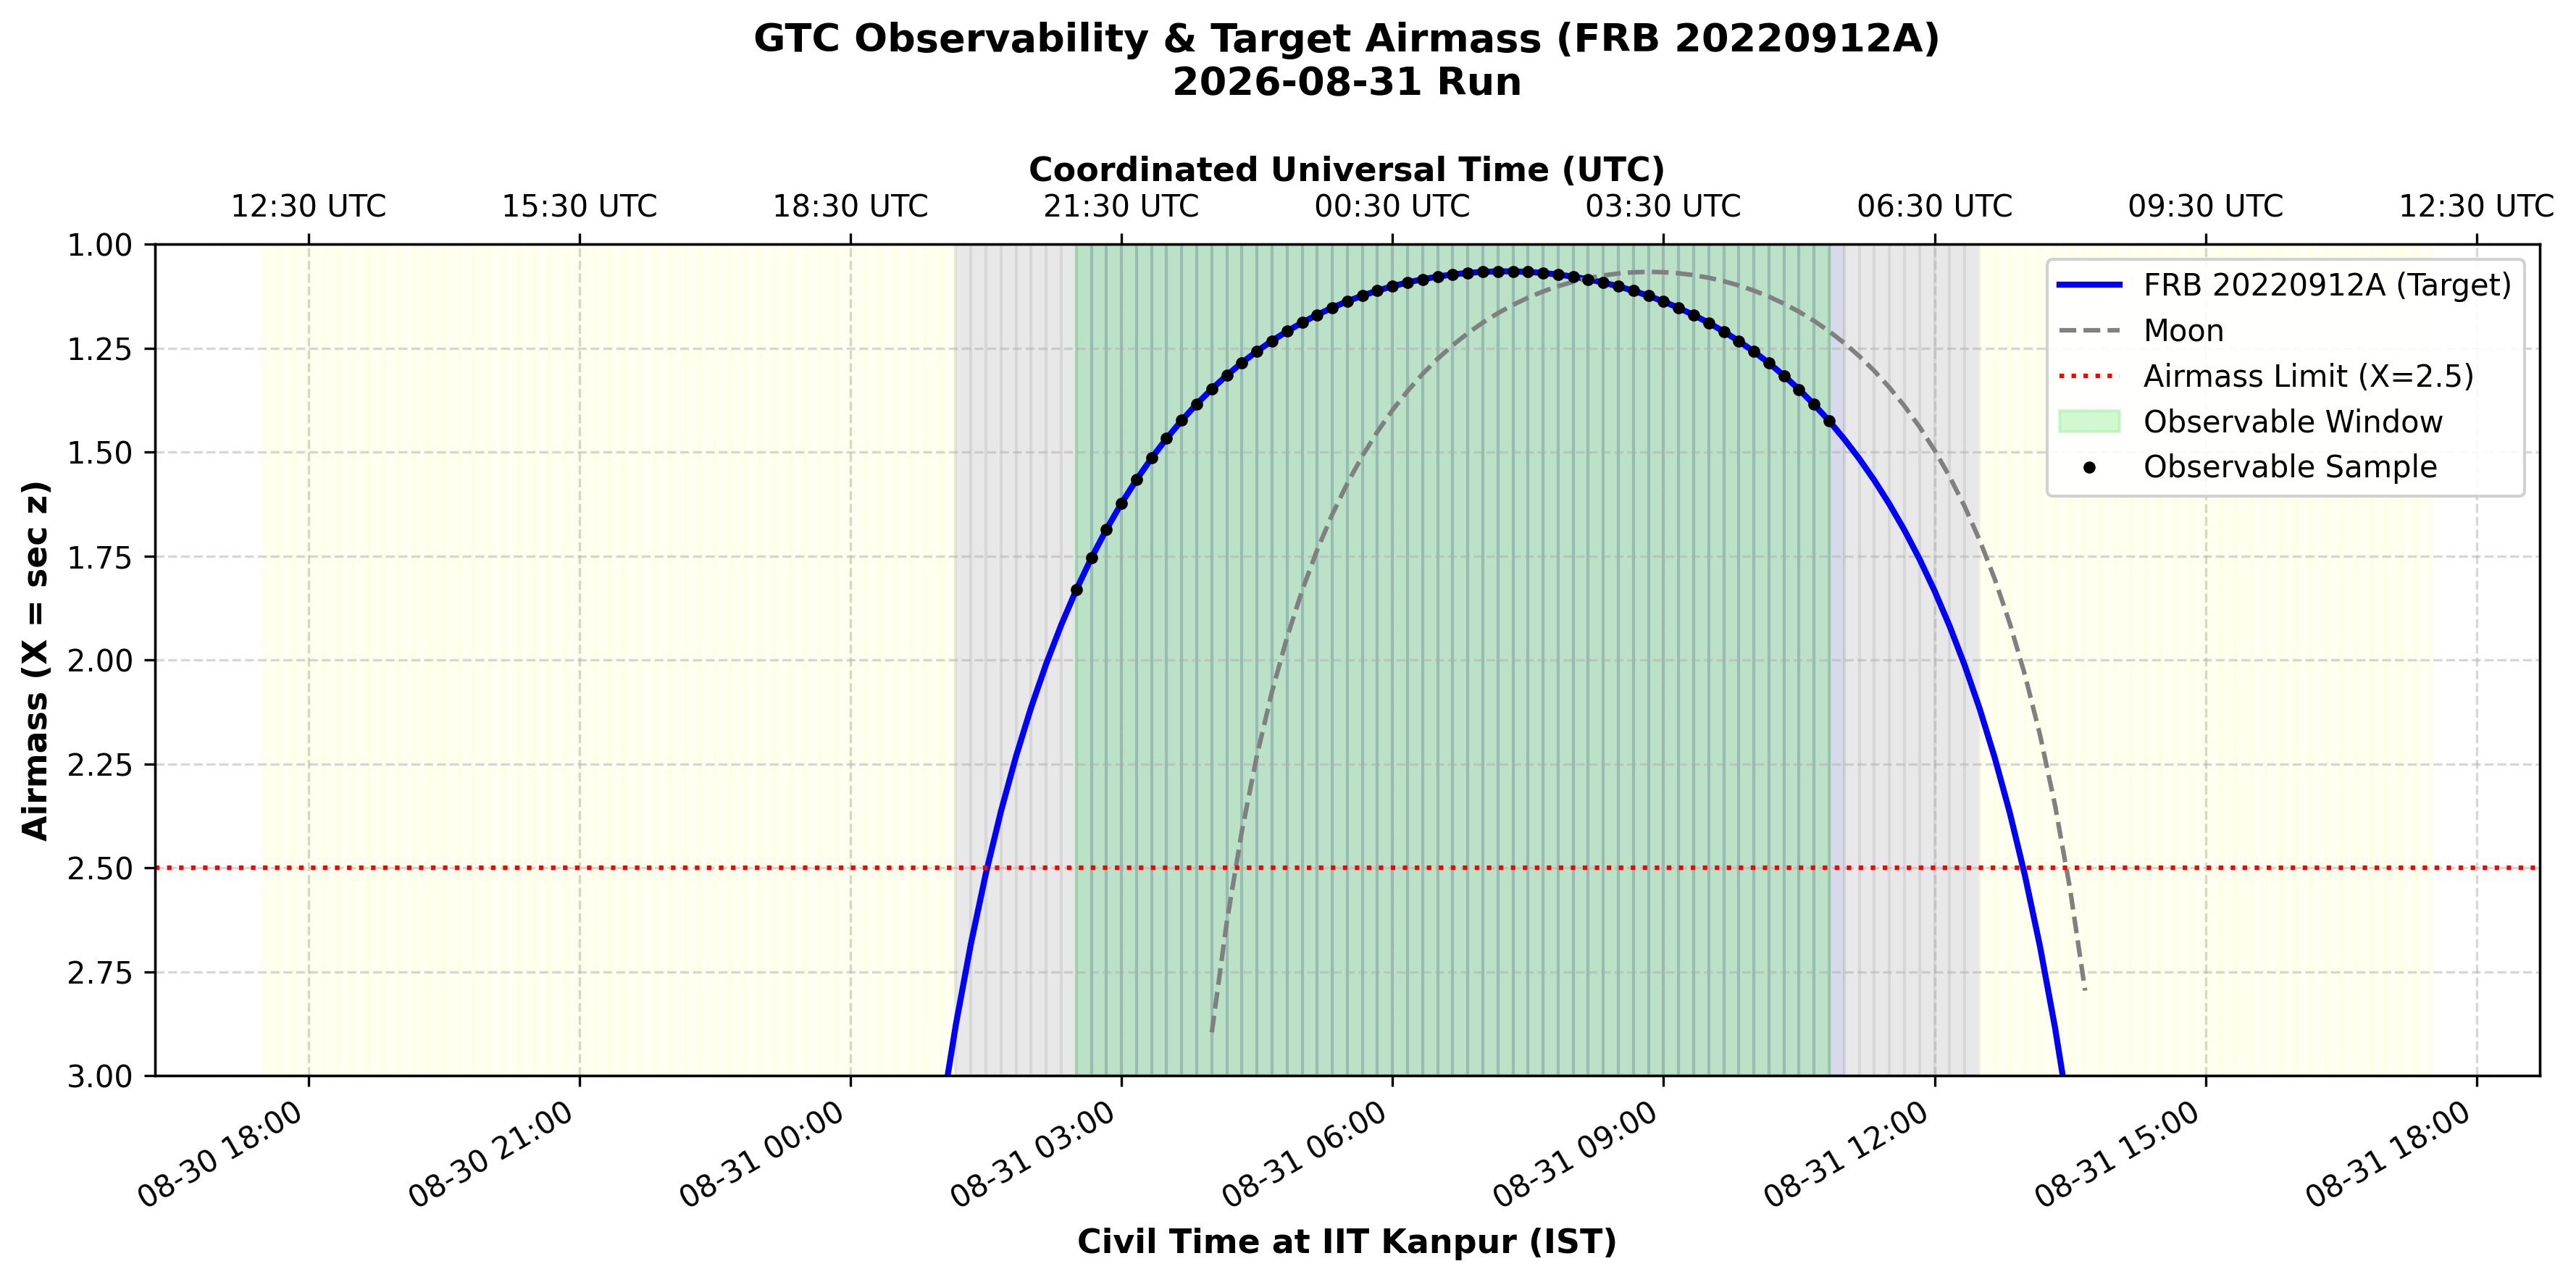

Figure succeassfully saved to: assignment_outputs/frb_20220912a_gtc_airmass.png


In [91]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def stitch_windows(times, visibility_state):
    visibility_state = np.asarray(visibility_state, dtype=bool)
    if not np.any(visibility_state):
        return []

    # Locate state transitions
    padded = np.concatenate([[False], visibility_state, [False]])
    diffs = np.diff(padded.astype(int))

    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0] - 1

    return list(zip(starts, ends))


intervals = stitch_windows(times, vis_mask)

print("Q18: Observable Window Report\n")
if not intervals:
    print("No observable windows found for the target under the specified constraints.")
else:
    for i, (s_idx, e_idx) in enumerate(intervals, 1):
        t_start_utc = times[s_idx]
        t_end_utc = times[e_idx]
        t_start_ist = format_iitk(t_start_utc)
        t_end_ist = format_iitk(t_end_utc)

        # Duration based on inclusive sample counts (10 min per sample)
        duration_samples = (e_idx - s_idx + 1)
        duration_hours = (duration_samples * 10.0) / 60.0

        # Best target airmass within window
        window_airmass = target_airmass[s_idx : e_idx + 1]
        best_X = np.nanmin(window_airmass)

        # Midpoint Moon label
        mid_idx = (s_idx + e_idx) // 2
        mid_moon_label = sky_classification[mid_idx]

        print(f"--- Window {i} ---")
        print(f"  UTC Range:            {t_start_utc.iso[:19]} to {t_end_utc.iso[:19]}")
        print(f"  IIT Kanpur Range:     {t_start_ist} to {t_end_ist}")
        print(f"  Sample-Centre Count: {duration_samples} samples ({duration_hours:.2f} hours)")
        print(f"  Best Target Airmass:  X = {best_X:.4f}")
        print(f"  Midpoint Moon Label:  {mid_moon_label}\n")

# output folder
os.makedirs("assignment_outputs", exist_ok=True)

# Converting to Python datetimes for plotting on x-axis
dates_ist = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]
dates_utc = [t.to_datetime() for t in times]

fig, ax1 = plt.subplots(figsize=(12, 6), dpi=300)

# Airmass Y-Axis (Inverted 3-to-1 Scale)
ax1.plot(dates_ist, target_airmass, color='blue', lw=2, label='FRB 20220912A (Target)')
ax1.plot(dates_ist, moon_airmass, color='gray', linestyle='--', lw=1.5, label='Moon')
ax1.axhline(2.5, color='red', linestyle=':', lw=1.5, label='Airmass Limit (X=2.5)')

ax1.set_ylim(3.0, 1.0)  # Inverted axis: 3 at bottom, 1 at top
ax1.set_ylabel("Airmass (X = sec z)", fontsize=11, fontweight='bold')

# Twilight Background Shading
for i in range(len(times) - 1):
    s_alt = sun_alt[i]
    if s_alt > 0.0:
        ax1.axvspan(dates_ist[i], dates_ist[i+1], color='lightyellow', alpha=0.5, zorder=0)  # Day
    elif s_alt > -18.0:
        ax1.axvspan(dates_ist[i], dates_ist[i+1], color='lightgray', alpha=0.5, zorder=0)    # Twilight
    else:
        ax1.axvspan(dates_ist[i], dates_ist[i+1], color='navy', alpha=0.15, zorder=0)        # Astro Night

# Highlight Observable Intervals
for s_idx, e_idx in intervals:
    # Green shading for interval
    ax1.axvspan(dates_ist[s_idx], dates_ist[e_idx], color='lightgreen', alpha=0.4, label='Observable Window')
    # Black markers for individual samples
    ax1.plot(np.array(dates_ist)[vis_mask], target_airmass[vis_mask], 'k.', markersize=6, label='Observable Sample')

# Deduplicate legend labels
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9)

# X-Axes Formatting
ax1.set_xlabel("Civil Time at IIT Kanpur (IST)", fontsize=11, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M', tz=IITK_TIMEZONE))
fig.autofmt_xdate()

# Secondary UTC X-Axis on top
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_xticklabels([mdates.num2date(x).astimezone(zoneinfo.ZoneInfo("UTC")).strftime('%H:%M UTC') for x in ax1.get_xticks()])
ax2.set_xlabel("Coordinated Universal Time (UTC)", fontsize=11, fontweight='bold')

ax1.set_title("GTC Observability & Target Airmass (FRB 20220912A)\n2026-08-31 Run", fontsize=13, pad=20, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
fig_path = "assignment_outputs/frb_20220912a_gtc_airmass.png"
plt.savefig(fig_path, dpi=300)
plt.close()

print(f"Figure succeassfully saved to: {fig_path}")

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [93]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

# 1. Generating 24-hour UTC grid for 2026-09-01 sampled every 10 minutes (144 samples)
t = Time('2026-09-01T00:00:00Z',   scale="utc")
grid_times = t + np.arange(0, 144) * (10 * u.min)

# Local AltAz frame at GTC
altaz_gtc = AltAz(location=gtc_location, obstime=grid_times)

# Target AltAz
frb_grid_altaz = frb_icrs.transform_to(altaz_gtc)

# Sun AltAz
sun_grid_altaz = get_sun(grid_times).transform_to(altaz_gtc)
target_airmass_grid = np.array(frb_grid_altaz.secz, dtype=float)

moon_grid_icrs = get_body('moon', grid_times)

# 2. Compute angular separation between FRB and Moon
moon_target_sep_grid = frb_icrs.separation(moon_grid_icrs)

is_visible_0901 = visibility(
    altitude=frb_grid_altaz.alt.deg,
    airmass=target_airmass_grid,
    sun_altitude=sun_grid_altaz.alt.deg,
    moon_separation=moon_target_sep_grid,
)

# 3. Stitch continuous windows and compute totals
windows_0901 = stitch_windows(grid_times, is_visible_0901)
total_visible_samples = np.sum(is_visible_0901)
total_hours = (total_visible_samples * 10) / 60.0


print("FRB 20220912A GTC Visibility Window for 2026-09-01\n")

total_visible_samples = np.sum(is_visible_0901)
total_hours = (total_visible_samples * 10) / 60.0

for i, (s_idx, e_idx) in enumerate(windows_0901, start=1):
  start_utc = grid_times[s_idx]
  end_utc = grid_times[e_idx]

  start_ist = format_iitk(start_utc)
  end_ist = format_iitk(end_utc)

  window_samples = e_idx - s_idx + 1
  window_hours = (window_samples * 10) / 60.0

  print(f"Continuous Visibility Window #{i}")
  print(f"  Start (UTC):  {start_utc.iso[:19]}")
  print(f"  End   (UTC):  {end_utc.iso[:19]}")
  print(f"  Start (IST):  {start_ist}")
  print(f"  End   (IST):  {end_ist}")
  print(
      f"  Duration:     {window_hours:.2f} hours ({window_samples} samples)\n"
  )

print(
    f"Total Visible Duration Across 2026-09-01: {total_hours:.2f} hours"
    f" ({total_visible_samples} / 144 samples)"
)

FRB 20220912A GTC Visibility Window for 2026-09-01

Continuous Visibility Window #1
  Start (UTC):  2026-09-01 00:00:00
  End   (UTC):  2026-09-01 05:20:00
  Start (IST):  2026-09-01 05:30:00 IST
  End   (IST):  2026-09-01 10:50:00 IST
  Duration:     5.50 hours (33 samples)

Continuous Visibility Window #2
  Start (UTC):  2026-09-01 21:00:00
  End   (UTC):  2026-09-01 23:50:00
  Start (IST):  2026-09-02 02:30:00 IST
  End   (IST):  2026-09-02 05:20:00 IST
  Duration:     3.00 hours (18 samples)

Total Visible Duration Across 2026-09-01: 8.50 hours (51 / 144 samples)


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [96]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
# Took the help of AI in this to understand the problem statement and apparoach

# 1. Set HEALPix Resolution (Nside=16 gives 3072 sky pixels, optimal for speed)
NSIDE = 16
NPIX = hp.nside2npix(NSIDE)
ipix = np.arange(NPIX)

# Compute celestial coordinates (RA, Dec) for all pixel centers
theta, phi = hp.pix2ang(NSIDE, ipix)
pixel_dec_deg = 90.0 - np.degrees(theta)
pixel_ra_deg = np.degrees(phi)
pixel_skycoord = SkyCoord(ra=pixel_ra_deg * u.deg, dec=pixel_dec_deg * u.deg, frame='icrs')

# 2. Setup Weekly Date Sequence (53 steps from 2026-08-30 to 2027-08-29)
start_date = Time("2026-08-30T00:00:00", scale="utc")
weekly_dates = start_date + np.arange(53) * 7 * u.day

frame_filenames = []

print("Generating 1-Year Weekly HEALPix Visibility Maps...")

for d_idx, date in enumerate(weekly_dates):
    # Sample 24-hour UTC grid (24 samples per day = 1-hour steps for performance)
    day_times = date + np.linspace(0, 24, 24, endpoint=False) * u.hour

    # Identify dark night time steps
    sun_alts = get_sun(day_times).transform_to(AltAz(location=gtc_location, obstime=day_times)).alt.deg
    dark_times = day_times[sun_alts <= -18.0]

    # Initialize observability map for pixels
    pixel_visible_hours = np.zeros(NPIX, dtype=float)

    if len(dark_times) > 0:
        # Check sky observability across dark times
        for t in dark_times:
            frame = AltAz(location=gtc_location, obstime=t)
            altaz_pix = pixel_skycoord.transform_to(frame)

            alts = altaz_pix.alt.deg
            airmasses = np.array(altaz_pix.secz, dtype=float)

            # Mask visible pixels (Altitude > 0 and 1.0 <= X <= 2.5)
            vis_mask = (alts > 0.0) & (airmasses >= 1.0) & (airmasses <= 2.5)
            pixel_visible_hours[vis_mask] += 1.0  # 1 hour per sample

    # Plot Mollweide Projection Frame
    plt.figure(figsize=(10, 6), dpi=150)
    hp.mollview(
        pixel_visible_hours,
        coord=['C'],
        title=f"GTC Observable Sky Visibility (Hours/Night)\nDate: {date.iso[:10]}",
        unit="Visible Hours",
        min=0, max=10,
        cmap="viridis",
        cbar=True
    )
    hp.graticule(dpar=30, dmer=30, alpha=0.3)

    frame_path = f"assignment_outputs/frame_{d_idx:02d}.png"
    plt.savefig(frame_path, bbox_inches='tight')
    plt.close()
    frame_filenames.append(frame_path)

# 3. Compile Frames into Animated GIF
gif_path = "assignment_outputs/gtc_allsky_year_visibility.gif"
with imageio.get_writer(gif_path, mode='I', duration=0.2) as writer:
    for filename in frame_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"\nSuccessfully created 1-Year Visibility GIF: {gif_path}")

Generating 1-Year Weekly HEALPix Visibility Maps...

Successfully created 1-Year Visibility GIF: assignment_outputs/gtc_allsky_year_visibility.gif


Seasonal variation in all-sky viewing window at GTC -

Throughout the 53 week animation, the main feature is the consistent eastward migration of observable skyband from one point in Right Ascension to the next, moving to higher RA by $\sim 2$ hr each month, or $\sim 1^{\circ}$ day$^{-1}$. This is characteristic of the movement along the ecliptic by the Earth over the course of a year, and thus altering which regions of the celestial sphere are within what viewing window (at a particular time after sunset), because the Sun (and its position on the ecliptic, thus determining local sunset/sunrise) moves along the ecliptic. Because of this change in RA over the year, targets that are blocked by day in one season will turn into prominent night sky viewing targets over half a year later.

Fixed by GTC's position ($+28.76^\circ\text{ N}$ lat.), however, is the southern boundary in Declination; far north stars, as before, are visible forever around RA $0^{\text{h}}$, and as before stars below $\sim -35^\circ$ Declination are permanently hidden.

The length of astronomical night, and therefore night sky visibility also varies seasonally from Northern Hemisphere winter into summer.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
